### Análise Exploratória de Dados (EDA)

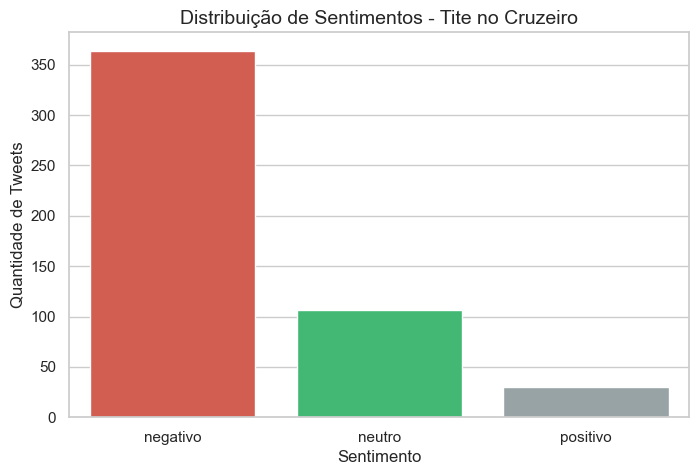

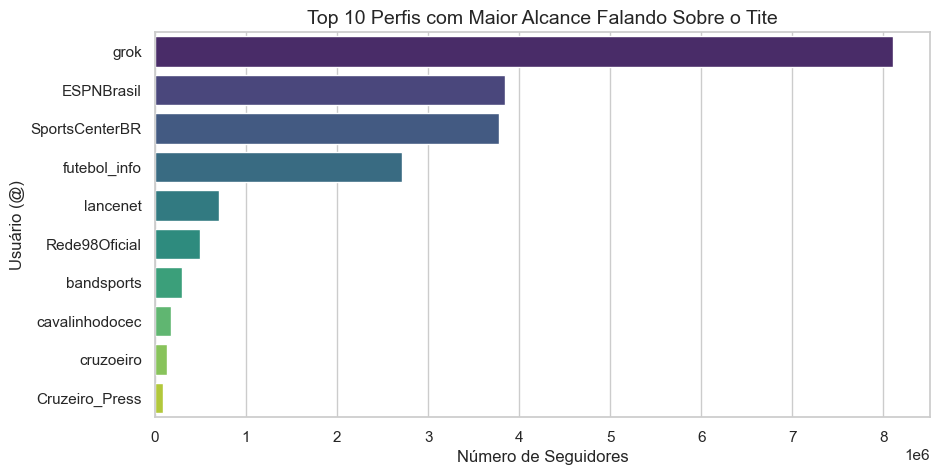

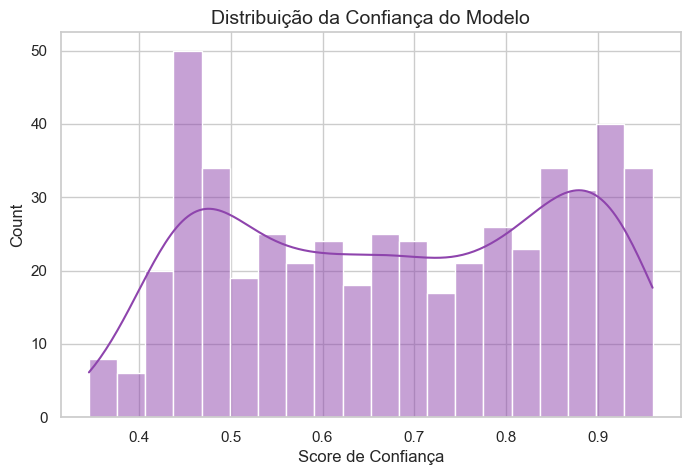

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/tweets_analise_final.csv")
df['criado_em'] = pd.to_datetime(df['criado_em'])

sns.set_theme(style="whitegrid")

# Gráfico da Distribuição de Sentimentos
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='sentimento_final', 
    hue='sentimento_final', 
    order=['negativo', 'neutro', 'positivo'], 
    palette=['#e74c3c', '#95a5a6', '#2ecc71'],
    legend=False
)
plt.title('Distribuição de Sentimentos - Tite no Cruzeiro', fontsize=14)
plt.ylabel('Quantidade de Tweets')
plt.xlabel('Sentimento')
plt.show()

# Top 10 Perfis com Mais Seguidores
plt.figure(figsize=(10, 5))
df_top_users = df.sort_values(by='seguidores', ascending=False).drop_duplicates(subset=['usuario']).head(10)

sns.barplot(
    data=df_top_users, 
    x='seguidores', 
    y='usuario', 
    hue='usuario',
    palette='viridis', 
    legend=False
)

plt.title('Top 10 Perfis com Maior Alcance Falando Sobre o Tite', fontsize=14)
plt.xlabel('Número de Seguidores')
plt.ylabel('Usuário (@)')
plt.show()

# Gráfico da Distribuição de Confiança
plt.figure(figsize=(8, 5))
sns.histplot(df['confianca'], bins=20, kde=True, color='#8e44ad')
plt.title('Distribuição da Confiança do Modelo', fontsize=14)
plt.xlabel('Score de Confiança')
plt.show()

### Análise de Engajamento

C:\Users\João Otávio\AppData\Local\Temp\ipykernel_5428\3030830355.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sentimento_final', y='engajamento_total', estimator='mean', errorbar=None, palette='viridis')


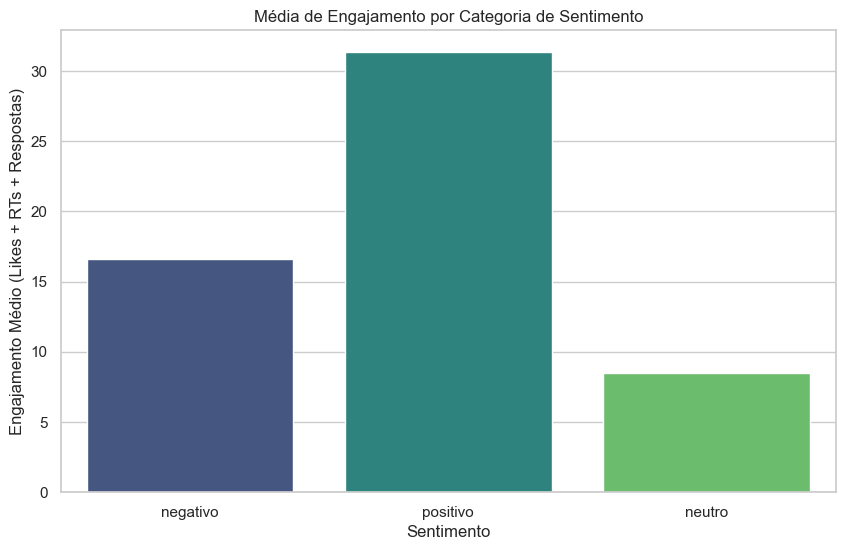

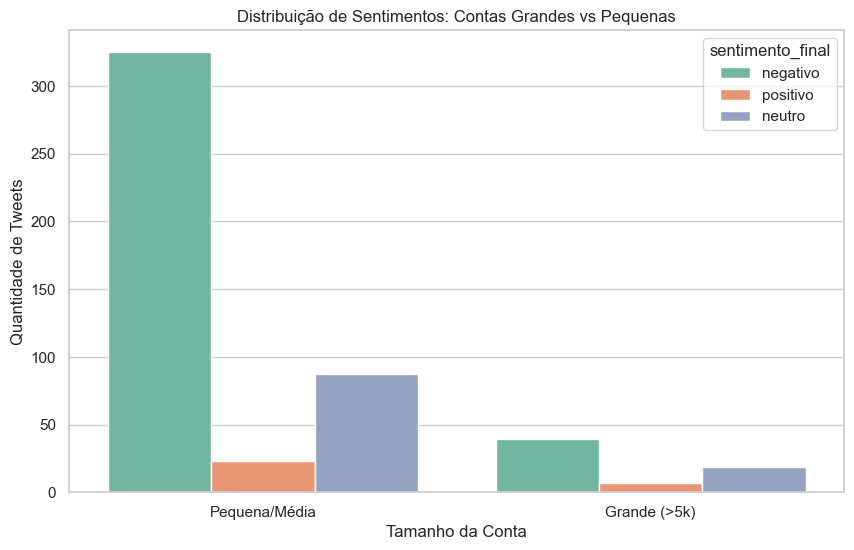

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols_engajamento = ['likes', 'retweets', 'respostas', 'seguidores']
for col in cols_engajamento:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Criar métrica de Engajamento Total
df['engajamento_total'] = df['likes'] + df['retweets'] + df['respostas']

# Correlação entre Sentimento e Engajamento
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='sentimento_final', y='engajamento_total', estimator='mean', errorbar=None, palette='viridis')
plt.title('Média de Engajamento por Categoria de Sentimento')
plt.ylabel('Engajamento Médio (Likes + RTs + Respostas)')
plt.xlabel('Sentimento')
plt.show()

# Influência de Contas Grandes vs. Contas Pequenas
# Definindo o que é uma "Conta Grande"
limite_seguidores = 5000
df['tamanho_conta'] = df['seguidores'].apply(lambda x: 'Grande (>5k)' if x >= limite_seguidores else 'Pequena/Média')

# Como o sentimento se divide entre contas grandes e pequenas?
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='tamanho_conta', hue='sentimento_final', palette='Set2')
plt.title('Distribuição de Sentimentos: Contas Grandes vs Pequenas')
plt.ylabel('Quantidade de Tweets')
plt.xlabel('Tamanho da Conta')
plt.show()